# Near field testing 17.03.2026

Choose one image that works correctly for each subband (1 without the signal generator and 1 with it for each)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import time
import datetime
import glob
import numpy as np

from lofarantpos.db import LofarAntennaDatabase

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, Normalize
import warnings
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
from matplotlib.ticker import FormatStrFormatter
import re

In [4]:
from astropy.coordinates import SkyCoord, GCRS, EarthLocation, AltAz, SkyOffsetFrame, CartesianRepresentation, get_sun, get_body
import astropy.units as u
from astropy.time import Time

In [5]:
# We need lofarantpos >= 0.4.0 to get the station rotations

from packaging import version
import lofarantpos
assert(version.parse(lofarantpos.__version__) >= version.parse("0.4.0"))

In [6]:
from lofarimaging import find_caltable, sb_from_freq, freq_from_sb, read_caltable, \
    read_acm_cube, get_map, sky_imager, ground_imager, get_station_pqr, get_station_type, \
    skycoord_to_lmn, nearfield_imager, make_leaflet_map, make_sky_plot, make_ground_plot, \
    apply_calibration, get_full_station_name, get_station_xyz

In [7]:
# We need python 3.6 for f-string formatting

assert(sys.version_info.major + 0.1*sys.version_info.minor >= 3.6)

In [8]:
# Define directories 
data_dir = "./test/museum_mode5_sb122"
caltable_dir = "./test/CalTables"  # Root directory under which station information is stored in subdirectories DE602C/etc/, RS106/etc/, ...

In [9]:
# Define area of interest
extent = [-300, 300, -300, 300]
pixels_per_metre = 0.3 # each pixel is 1km
height = 5 #meters

In [10]:
os.makedirs('results', exist_ok=True)
start1 = time.time()

In [11]:
# Read all available .dat files
print(f"Searching for available files in {data_dir}")
files = glob.glob(data_dir + "/*.dat")
for file_index, filename in enumerate(files):
    print(f"{file_index}: {filename}")

Searching for available files in ./test/museum_mode5_sb122
0: ./test/museum_mode5_sb122\20260317_111338_xst.dat
1: ./test/museum_mode5_sb122\20260317_111523_xst.dat
2: ./test/museum_mode5_sb122\20260317_111711_xst.dat
3: ./test/museum_mode5_sb122\20260317_111903_xst.dat
4: ./test/museum_mode5_sb122\20260317_112057_xst.dat


In [12]:
# Select a file
xst_filename = files[4]

print("File selected:", xst_filename)

File selected: ./test/museum_mode5_sb122\20260317_112057_xst.dat


In [13]:
station_name = "LV614"

# RCU Mode: defines usable frequency band and filter characteristics
rcu_mode = xst_filename.split('mode')[1].split('_')[0]
print(rcu_mode)
subband = int(xst_filename.split('sb')[1].split('\\')[0])
print(subband)

obsdatestr, obstimestr, *_ = os.path.basename(xst_filename).rstrip(".dat").split("_")

5
122


In [14]:
station_type = get_station_type(station_name)

In [15]:
station_name = get_full_station_name(station_name, rcu_mode)

# Get the data
fname = f"{obsdatestr}_{obstimestr}_{station_name}_SB{subband}"

npix_l, npix_m = 131, 131
freq = freq_from_sb(subband, rcu_mode=rcu_mode)

# Which slice in time to visualise
timestep = 0

# For ground imaging
ground_resolution = pixels_per_metre  # pixels per metre for ground_imaging, default is 0.5 pixel/metre

obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')
print(obstime)

# Confirm the data has been read correctly
print(f"""Station: {station_name}
Station type: {station_type}
Subband: {subband}
Timestep: {timestep}
Save title: {fname}
Sky image size: {npix_l:d} x {npix_m:d}
Ground image extent: {extent[1]-extent[0]:d} x {extent[3]-extent[2]:d} m
Ground height: {height} m\
""")

2026-03-17 11:20:57
Station: LV614HBA
Station type: intl
Subband: 122
Timestep: 0
Save title: 20260317_112057_LV614HBA_SB122
Sky image size: 131 x 131
Ground image extent: 600 x 600 m
Ground height: 5 m


In [16]:
# Read AutoCorrelation Matrix cube
cube = read_acm_cube(xst_filename, station_type)

In [17]:
cube, calibration_info = apply_calibration(cube, station_name, rcu_mode, subband, caltable_dir=caltable_dir)

In [18]:
# Split into the XX and YY polarisations (RCUs)
# This needs to be modified in future for LBA sparse
cube_xx = cube[:, 0::2, 0::2]
cube_yy = cube[:, 1::2, 1::2]
visibilities_all = cube_xx + cube_yy

# Stokes I for specified timestep
visibilities = visibilities_all[timestep]

In [19]:
# Check the resulting cubes have half the size
cube_xx.shape, cube_yy.shape, visibilities_all.shape, visibilities.shape, visibilities.dtype

((60, 96, 96), (60, 96, 96), (60, 96, 96), (96, 96), dtype('complex128'))

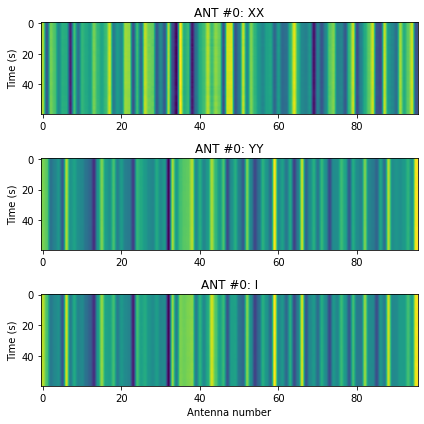

In [20]:
# Check how the various antennas/polarisation look with time
# TODO maybe change antenna number bc this isn't right
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, figsize=(6,6))

ax0.imshow(cube_xx[:, 0, :].real, aspect='auto')
ax0.set_ylabel('Time (s)')
ax0.set_title('ANT #0: XX')
ax1.imshow(cube_yy[:,0,:].real,aspect='auto')
ax1.set_title('ANT #0: YY')
ax1.set_ylabel('Time (s)')
ax2.imshow(visibilities_all[:,0,:].real,aspect='auto')
ax2.set_title('ANT #0: I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Time (s)')
fig1.tight_layout()

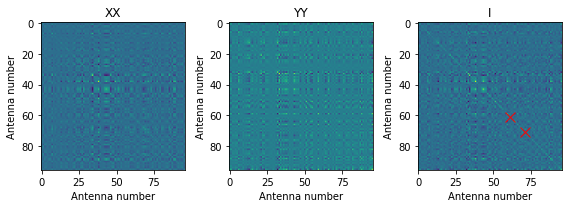

In [21]:
# Check how the correlations look
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(8,3))

ax0.imshow(cube_xx[0,:,:].real, aspect='auto')
ax0.set_xlabel('Antenna number')
ax0.set_ylabel('Antenna number')
ax0.set_title('XX')
ax1.imshow(cube_yy[0,:,:].real, aspect='auto')
ax1.set_title('YY')
ax1.set_xlabel('Antenna number')
ax1.set_ylabel('Antenna number')
ax2.imshow(visibilities.real, aspect='auto')
ax2.set_title('I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Antenna number')

ax2.plot(61, 61, marker='x', color='red', markersize=10)
ax2.plot(71, 71, marker='x', color='red', markersize=10)


fig1.tight_layout()

In [22]:
# Setup the database
db = LofarAntennaDatabase()

In [23]:
station_xyz, pqr_to_xyz = get_station_xyz(station_name, rcu_mode, db)

In [24]:
# For every antenna, calculate the distance between it and every other antenna
baselines = station_xyz[:, np.newaxis, :] - station_xyz[np.newaxis, :, :]

In [25]:
# Account for the rotation
rotation = np.rad2deg(db.rotation_from_north(station_name))
print ('Rotation for %s: %.2f deg' % (station_name, rotation))

Rotation for LV614HBA: 12.73 deg


In [26]:
obstime_astropy = Time(obstime)
# Determine positions of Cas A and Cyg A
# Irbene station location:
station_earthlocation = EarthLocation.from_geocentric(*(db.phase_centres[station_name] * u.m))

zenith = AltAz(az=0 * u.deg, alt=90 * u.deg, obstime=obstime_astropy,
               location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy))

marked_bodies = {
    'Cas A': SkyCoord(ra=350.858*u.deg, dec=58.811*u.deg),
    'Cyg A': SkyCoord(ra=299.868*u.deg, dec=40.734*u.deg),
#        'Per A': SkyCoord.from_name("Perseus A"),
#        'Her A': SkyCoord.from_name("Hercules A"),
#        'Cen A': SkyCoord.from_name("Centaurus A"),
#        '?': SkyCoord.from_name("J101415.9+105106"),
#        '3C295': SkyCoord.from_name("3C295"),
#        'Moon': get_moon(obstime_astropy, location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy)),
#    'Sun': get_sun(obstime_astropy) eclipse
#        '3C196': SkyCoord.from_name("3C196")
}

############# NEW
marked_sats = {}
marked_sats_traj = {}   

from skyfield.api import wgs84, load

print(f"Lat: {station_earthlocation.lat.deg}, Lon: {station_earthlocation.lon.deg}, Alt: {station_earthlocation.height}")

# tranform astropy object to skyfield
station_location = wgs84.latlon(
    station_earthlocation.lat.deg, 
    station_earthlocation.lon.deg, 
    elevation_m=station_earthlocation.height.to(u.m).value
)

from datetime import timedelta

ts = load.timescale()
# t = ts.now()  # for real time
t = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second)

######## for movement prediction
secs = np.arange(0, 300, 5) 
t_array = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second + secs)

obstime_start = obstime - timedelta(days=1) # range of 1 day before observation to ensure most recent TLE at that time
start_date_str = obstime_start.strftime('%Y-%m-%d %H:%M:%S')
end_date_str = obstime.strftime('%Y-%m-%d %H:%M:%S')

from spacetrack import get_starlink_data

# load Starlink data
satellites = get_starlink_data(start_date_str, end_date_str)
# satellites = load.tle_file('https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle')

for sat in satellites:
    # relative position to Irbene
    difference = sat - station_location
    topocentric = difference.at(t) # TLE does not download the satellite's current position
                                   # but rather its orbital parameters.
                                   # It calculates the position using a mathematical model (SGP4) with .at(t)

    # obtain altitude and azimuth
    alt, az, distance = topocentric.altaz()

    # above horizon (Alt > 30)
    if alt.degrees > 30: 
        ra, dec, distance = topocentric.radec()
        # print(f"{sat.name}: Right ascension {ra.hours:.2f} h, Declination {dec.degrees:.2f}°")
        marked_sats[sat.name] = SkyCoord(ra=ra.hours*u.hourangle, dec=dec.degrees*u.deg)
        
        # save trajectory
        trajectory = difference.at(t_array)
        ra_traj, dec_traj, _ = trajectory.radec()
        marked_sats_traj[sat.name] = SkyCoord(ra=ra_traj.hours*u.hourangle, dec=dec_traj.degrees*u.deg)

marked_sats_lmn = {}
for sat_name, sat_coord in marked_sats.items():
    marked_sats_lmn[sat_name] = skycoord_to_lmn(marked_sats[sat_name], zenith)
    
marked_sats_traj_lmn = {}
for sat_name, sat_traj in marked_sats_traj.items():
    marked_sats_traj_lmn[sat_name] = skycoord_to_lmn(sat_traj, zenith)

# print(marked_sats)
# print(marked_sats_lmn)

marked_bodies_lmn = {}
for body_name, body_coord in marked_bodies.items():
    #print(body_name, body_coord.separation(zenith), body_coord.separation(zenith))
    if body_coord.transform_to(AltAz(location=station_earthlocation, obstime=obstime_astropy)).alt > 0:
        marked_bodies_lmn[body_name] = skycoord_to_lmn(marked_bodies[body_name], zenith)
        
marked_all_lmn = {**marked_bodies_lmn, **marked_sats_lmn}

Lat: 57.55746378635328, Lon: 21.855719969772288, Alt: 13.299870098323728 m
Data downloaded, converting to Skyfield objects...


In [27]:
from lofarimaging import subtract_sources

In [28]:
visibilities_subtracted = subtract_sources(visibilities, baselines, freq, marked_bodies_lmn)

In [29]:
npix_x, npix_y = int(ground_resolution * (extent[1] - extent[0])), int(ground_resolution * (extent[3] - extent[2]))
print(npix_x, npix_y)

180 180


In [30]:
import lofargeotiff

In [31]:
# Convert bottom left and upper right to PQR just for lofargeo
pmin, qmin, _ = pqr_to_xyz.T @ (np.array([extent[0], extent[2], 0]))
pmax, qmax, _ = pqr_to_xyz.T @ (np.array([extent[1], extent[3], 0]))
lon_center, lat_center, _ = lofargeotiff.pqr_to_longlatheight([0, 0, 0], station_name)
lon_min, lat_min, _ = lofargeotiff.pqr_to_longlatheight([pmin, qmin, 0], station_name)
lon_max, lat_max, _ = lofargeotiff.pqr_to_longlatheight([pmax, qmax, 0], station_name)
lon_min, lat_min, lon_max, lat_max

(21.85070870652665, 57.55476996395782, 21.860731972902613, 57.56015740873865)

In [32]:
background_map = get_map(lon_min, lon_max, lat_min, lat_max, 18)

In [33]:
os.environ["NUMEXPR_NUM_THREADS"] = "3"

In [34]:
# Select a subset of visibilities, only the lower triangular part
baseline_indices = np.tril_indices(visibilities.shape[0])

In [35]:
visibilities_selection = visibilities_subtracted[baseline_indices]

In [36]:
print(npix_x, npix_y)
%time img = nearfield_imager(visibilities_selection.flatten()[:,np.newaxis], \
                             np.array(baseline_indices).T, \
                             [freq], npix_x, npix_y, extent, station_xyz, height=height)
# Correct for taking only lower triangular part
img = np.real(2 * img)
img = 10 * np.log10(np.abs(img))

180 180
CPU times: total: 21.2 s
Wall time: 8.81 s


In [37]:
# Make colors semi-transparent in the lower 3/4 of the scale
cmap = cm.Spectral_r
cmap_with_alpha = cmap(np.arange(cmap.N))
cmap_with_alpha[:, -1] = np.clip(np.linspace(0, 1.5, cmap.N), 0., 1.)
cmap_with_alpha = ListedColormap(cmap_with_alpha)

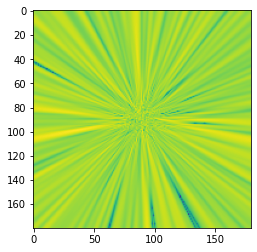

In [38]:
for sat in satellites:
    # get the satellite's position at time 't'
    geocentric = sat.at(t)
    
    # get geographic coordinates
    subpoint = geocentric.subpoint()
    sat_lat = subpoint.latitude.degrees
    sat_lon = subpoint.longitude.degrees
    
    # check if satellite is within map boundaries
    if (lon_min <= sat_lon <= lon_max) and (lat_min <= sat_lat <= lat_max):
        ax.plot(sat_lon, sat_lat, marker='x', color='white', markersize=8, zorder=10)
        ax.text(sat_lon + 0.05, sat_lat, f" {sat.name}", color='white', fontsize=9, zorder=10)
        
plt.imshow(img)

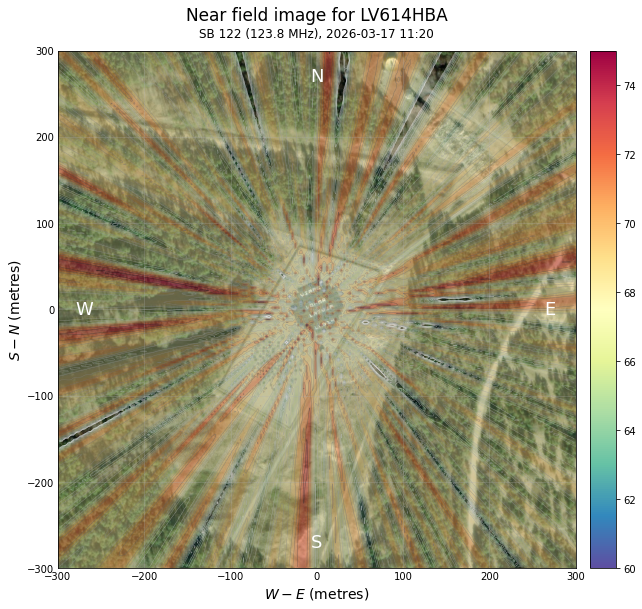

In [47]:
fig, folium_overlay = make_ground_plot(img, background_map, extent,
                                       title=f"Near field image for {station_name}",
                                       subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                                       vmin = 60, vmax = 75,
                                       opacity=0.5, db_format = True)

In [40]:
maxpixel_ypix, maxpixel_xpix = np.unravel_index(np.argmax(img), img.shape)
maxpixel_x = np.interp(maxpixel_xpix, [0, npix_x], [extent[0], extent[1]])
maxpixel_y = np.interp(maxpixel_ypix, [0, npix_y], [extent[2], extent[3]])
[maxpixel_p, maxpixel_q, _] = pqr_to_xyz.T @ np.array([maxpixel_x, maxpixel_y, height])
maxpixel_lon, maxpixel_lat, _ = lofargeotiff.pqr_to_longlatheight([maxpixel_p, maxpixel_q], station_name)

In [41]:
# Show location of maximum if not at the image border
if 5 < maxpixel_xpix < npix_x - 5 and 5 < maxpixel_ypix < npix_y - 5:
    print(f"Maximum at {maxpixel_x:.0f}m east, {maxpixel_y:.0f}m north of station center (lat/long {maxpixel_lat:.5f}, {maxpixel_lon:.5f})")

Maximum at -167m east, 27m north of station center (lat/long 57.55770, 21.85294)


In [42]:
# Check total time to run
end1 = time.time()
print ('Time elapsed: %.2f s' % (end1-start1))

Time elapsed: 47.54 s


In [43]:
obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')

In [44]:
tags = {"datafile": xst_filename,
        "generated_with": f"lofarimaging notebook",
        "subband": subband,
        "frequency": freq,
        "extent_xyz": extent,
        "height": height,
        "station": station_name,
        "pixels_per_metre": pixels_per_metre}
tags.update(calibration_info)
lofargeotiff.write_geotiff(img, f"results/{fname}_nearfield_calibrated.tiff",
                           (pmin, qmin), (pmax, qmax), stationname=station_name,
                           obsdate=obstime, tags=tags)


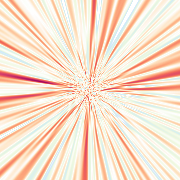

In [45]:
make_leaflet_map(folium_overlay, lon_center, lat_center, lon_min, lat_min, lon_max, lat_max)